# 07 - Newham Spatial Maps

Plots two maps for Newham:
1. **Graph map** — comment and application locations connected by edges.
2. **Topic map** — comment locations coloured by their primary topic.

In [6]:
import sys
sys.path.append("../functions")

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point

from config import (
    RESULTS_DIR, FIGURES_DIR, LONDON_LAD_FILE,
    FINETUNED_MODEL_DIR, BAD_TOPICS,
)
from topic_processing import build_topic_names

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load data (local only — no DB connection needed)

In [7]:
comments           = pd.read_parquet(RESULTS_DIR / "comments.parquet")
pld                = pd.read_parquet(RESULTS_DIR / "pld.parquet")
raw_topic_names    = pd.read_csv(FINETUNED_MODEL_DIR / "object_topics.csv")
raw_comment_topics = pd.read_csv(FINETUNED_MODEL_DIR / "object_comments_with_topics.csv")

topic_names     = build_topic_names(raw_topic_names)
topic_color_map = topic_names.set_index("Topic")["color"].to_dict()
topic_group_map = topic_names.set_index("Topic")["topic_group"].to_dict()

lad              = gpd.read_file(LONDON_LAD_FILE)
newham_boundary  = lad[lad["LAD24NM"] == "Newham"]

print(f"comments: {len(comments):,}  |  pld: {len(pld):,}")
print(f"Newham boundary loaded: {len(newham_boundary)} polygon(s)")

comments: 30,393  |  pld: 28,804
Newham boundary loaded: 1 polygon(s)


## Process — filter to Newham, extract centroids, join topics

In [ ]:

# --- Filter to Newham ---
newham_c   = comments[comments["council"] == "Newham"].copy()
newham_pld = pld[pld["borough"] == "Newham"].copy()

# --- Extract application centroids from nested numpy coordinate arrays ---
def _centroid(coords):
    try:
        ring = np.vstack(coords[0])      # shape (n_points, 2): [lon, lat]
        return float(ring[:, 1].mean()), float(ring[:, 0].mean())  # lat, lon
    except Exception:
        return np.nan, np.nan

lats, lons = zip(*newham_pld["wgs84_polygon.coordinates"].map(_centroid))
newham_pld = newham_pld.copy()
newham_pld["centroid_lat"] = lats
newham_pld["centroid_lon"] = lons
app_centroids = (
    newham_pld
    .dropna(subset=["centroid_lat", "centroid_lon"])
    .drop_duplicates("lpa_app_no")
)

# --- Attach application centroid to each comment ---
newham_c = newham_c.merge(
    app_centroids[["lpa_app_no", "centroid_lat", "centroid_lon"]],
    left_on="application_id", right_on="lpa_app_no", how="left",
)

# --- Derive primary topic (first non-bad topic in the topic list) ---
BAD_SET = set(BAD_TOPICS)

def _parse_list(val):
    return ast.literal_eval(val) if isinstance(val, str) else list(val)

def _primary_topic(val):
    for t in _parse_list(val):
        if t not in BAD_SET:
            return int(t)
    return None

raw_comment_topics["topic_list"]    = raw_comment_topics["topic"].apply(_parse_list)
raw_comment_topics["primary_topic"] = raw_comment_topics["topic"].apply(_primary_topic)

newham_c = newham_c.merge(
    raw_comment_topics[["comment_id", "primary_topic", "topic_list"]],
    on="comment_id", how="left",
)
newham_c["topic_color"] = newham_c["primary_topic"].map(topic_color_map).fillna("#666666")
newham_c["topic_label"] = newham_c["primary_topic"].map(topic_group_map).fillna("unclassified")

# --- Wrong housing type: topic 10 anywhere in topic list ---
WRONG_HOUSING_TOPIC = 10
wrong_housing_ids = set(
    raw_comment_topics[
        raw_comment_topics["topic_list"].apply(lambda lst: WRONG_HOUSING_TOPIC in lst)
    ]["comment_id"]
)
newham_c["wrong_housing"] = newham_c["comment_id"].isin(wrong_housing_ids)

# --- Filtered application sets ---
# Applications with at least one comment (Maps 1–3)
apps_with_comments = set(newham_c["application_id"].dropna())
app_centroids_commented = app_centroids[app_centroids["lpa_app_no"].isin(apps_with_comments)]

# Applications with at least one wrong-housing-type comment (Map 4)
apps_with_wrong_housing = set(newham_c[newham_c["wrong_housing"]]["application_id"].dropna())
app_centroids_wrong_housing = app_centroids[app_centroids["lpa_app_no"].isin(apps_with_wrong_housing)]

# Only rows with both comment and application coordinates
linked = newham_c.dropna(subset=["lat", "lon", "centroid_lat", "centroid_lon"])

# Newham bounding box (used to clip map extent)
_bounds = newham_boundary.to_crs("EPSG:4326").total_bounds
_pad = 0.04
MAP_XLIM = (_bounds[0] - _pad, _bounds[2] + _pad)
MAP_YLIM = (_bounds[1] - _pad, _bounds[3] + _pad)

print(f"Newham comments:                  {len(newham_c):,}")
print(f"  with coordinates:               {newham_c[['lat','lon']].dropna().shape[0]:,}")
print(f"  with topic assigned:            {newham_c['primary_topic'].notna().sum():,}")
print(f"  wrong housing type (any):       {newham_c['wrong_housing'].sum():,}")
print(f"  linkable (comment + app):       {len(linked):,}")
print(f"Applications (all Newham):        {len(app_centroids):,}")
print(f"Applications (≥1 comment):        {len(app_centroids_commented):,}")
print(f"Applications (wrong housing ≥1):  {len(app_centroids_wrong_housing):,}")


Newham comments:                  750
  with coordinates:               746
  with topic assigned:            569
  wrong housing type (any):       52
  linkable (comment + app):       544
Applications (all Newham):        701
Applications (≥1 comment):        144
Applications (wrong housing ≥1):  32


## Map 1 — Comments connected to applications (graph)

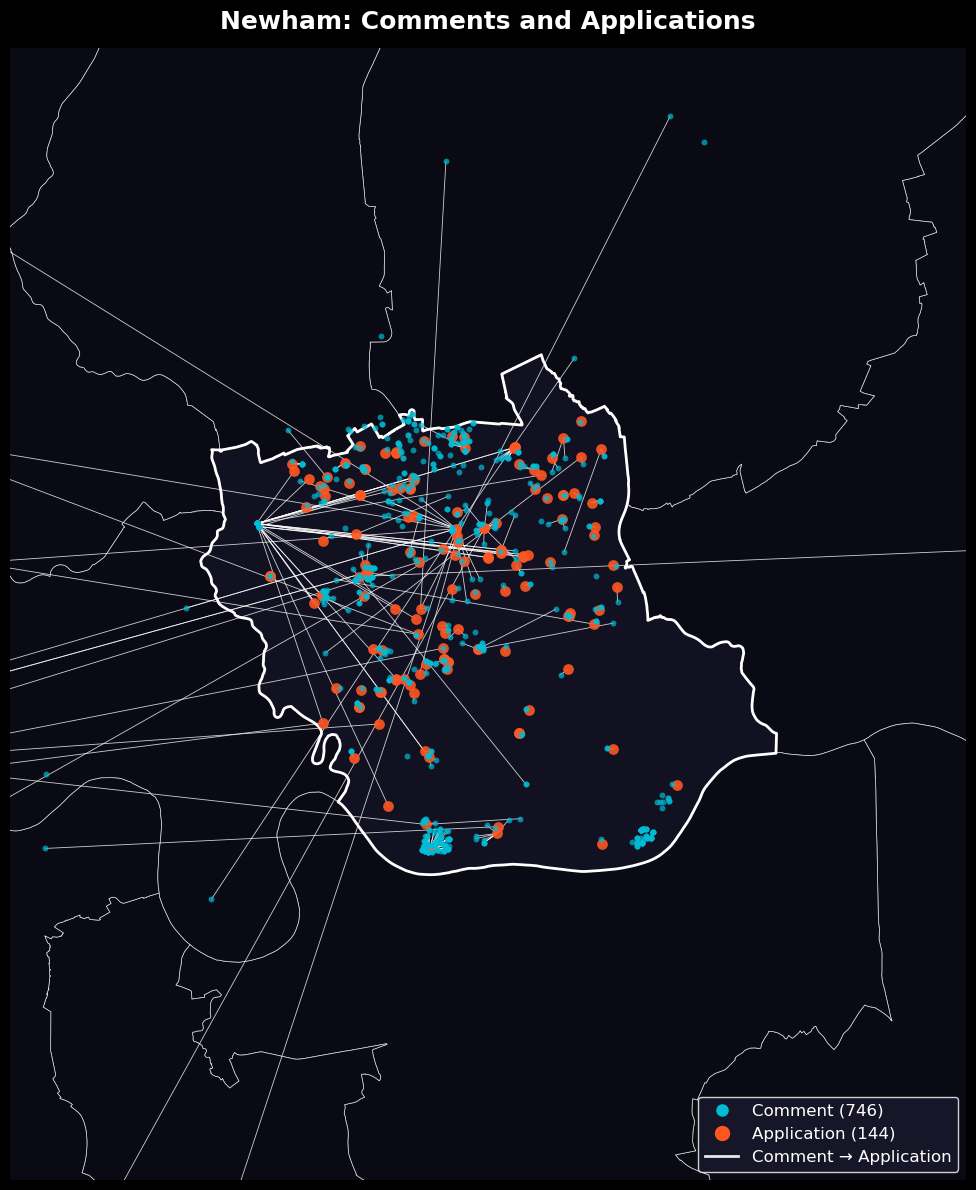

In [ ]:

def _base_map(ax, title):
    """Draw London borough outlines + highlighted Newham boundary."""
    ax.set_facecolor("black")
    lad.to_crs("EPSG:4326").plot(
        ax=ax, color="#0d0d1a", edgecolor="white", linewidth=0.5, alpha=0.8,
    )
    newham_boundary.to_crs("EPSG:4326").plot(
        ax=ax, color="#111122", edgecolor="white", linewidth=2.0,
    )
    ax.set_xlim(*MAP_XLIM)
    ax.set_ylim(*MAP_YLIM)
    ax.set_axis_off()
    ax.set_title(title, color="white", fontsize=18, fontweight="bold", pad=14)

# ── Map 1: graph ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")
_base_map(ax, "Newham: Comments and Applications")

for _, row in linked.iterrows():
    ax.plot(
        [row["lon"], row["centroid_lon"]],
        [row["lat"], row["centroid_lat"]],
        color="white", alpha=0.8, linewidth=0.6, zorder=1,
    )

has_coords = newham_c.dropna(subset=["lat", "lon"])
ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#ff5722", s=60, alpha=0.9, zorder=3, linewidths=0,
)
ax.scatter(
    has_coords["lon"], has_coords["lat"],
    color="#00bcd4", s=18, alpha=0.7, zorder=4, linewidths=0,
)

legend_handles = [
    mlines.Line2D([], [], color="#00bcd4", marker="o", linestyle="None",
                  markersize=8, label=f"Comment ({len(has_coords)})"),
    mlines.Line2D([], [], color="#ff5722", marker="o", linestyle="None",
                  markersize=10, label=f"Application ({len(app_centroids_commented)})"),
    mlines.Line2D([], [], color="white", alpha=0.9, linewidth=2,
                  label="Comment → Application"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor="#1a1a2e", edgecolor="white", labelcolor="white", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "newham_comment_application_graph.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Map 2 — Comments coloured by topic

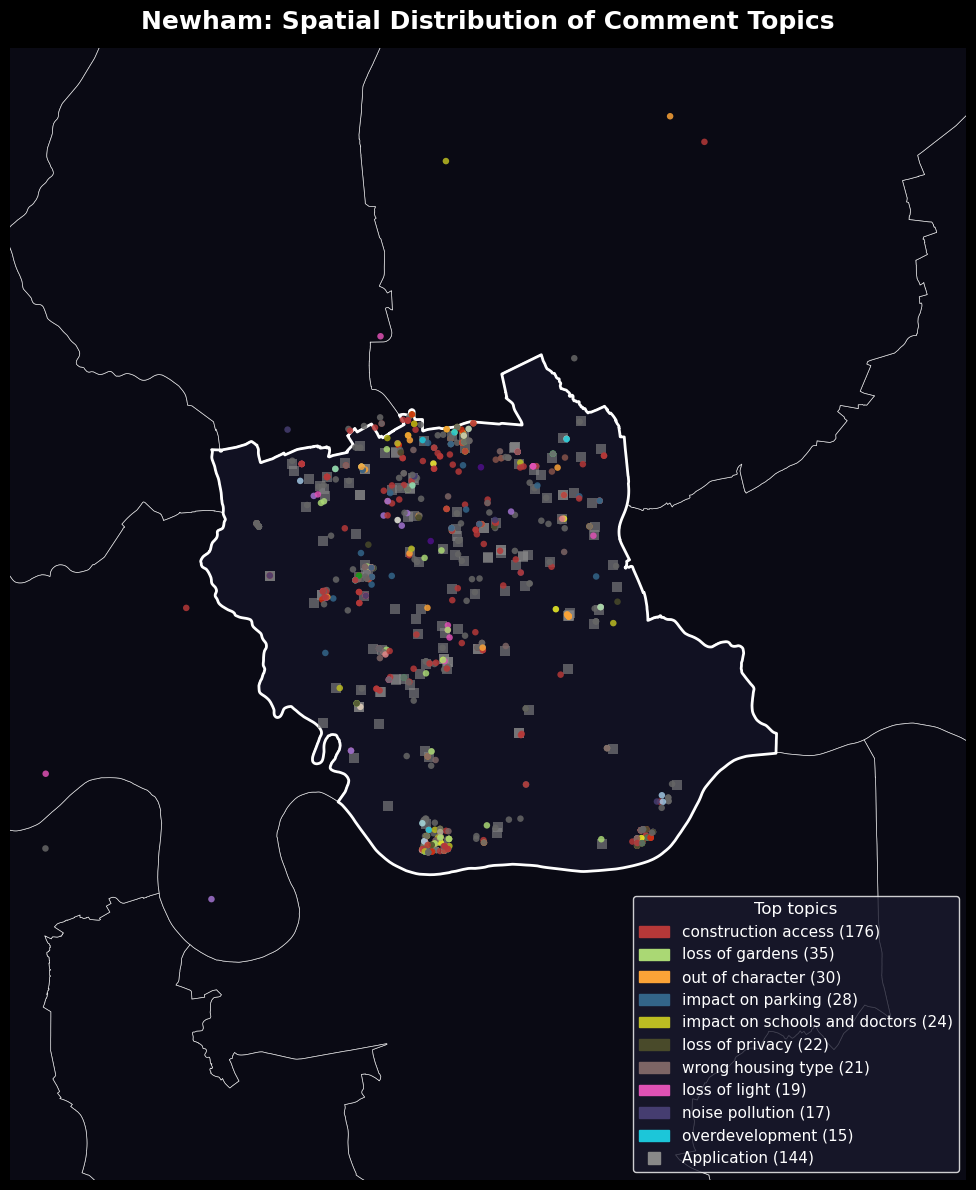

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")
_base_map(ax, "Newham: Spatial Distribution of Comment Topics")

ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#888888", s=50, alpha=0.6, zorder=2, linewidths=0, marker="s",
)

has_coords = newham_c.dropna(subset=["lat", "lon"])
ax.scatter(
    has_coords["lon"], has_coords["lat"],
    c=has_coords["topic_color"], s=22, alpha=0.85, zorder=3, linewidths=0,
)

topic_counts = (
    has_coords.dropna(subset=["primary_topic"])
    .groupby(["primary_topic", "topic_label", "topic_color"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)
legend_handles = [
    mpatches.Patch(color=row["topic_color"], label=f"{row['topic_label']} ({row['n']})")
    for _, row in topic_counts.iterrows()
]
legend_handles.append(
    mlines.Line2D([], [], color="#888888", marker="s", linestyle="None",
                  markersize=8, label=f"Application ({len(app_centroids_commented)})")
)
leg = ax.legend(handles=legend_handles, loc="lower right",
                facecolor="#1a1a2e", edgecolor="white", labelcolor="white",
                fontsize=11, title="Top topics", title_fontsize=12)
leg.get_title().set_color("white")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "newham_comment_topics_map.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Map 3 — Wrong housing type comments

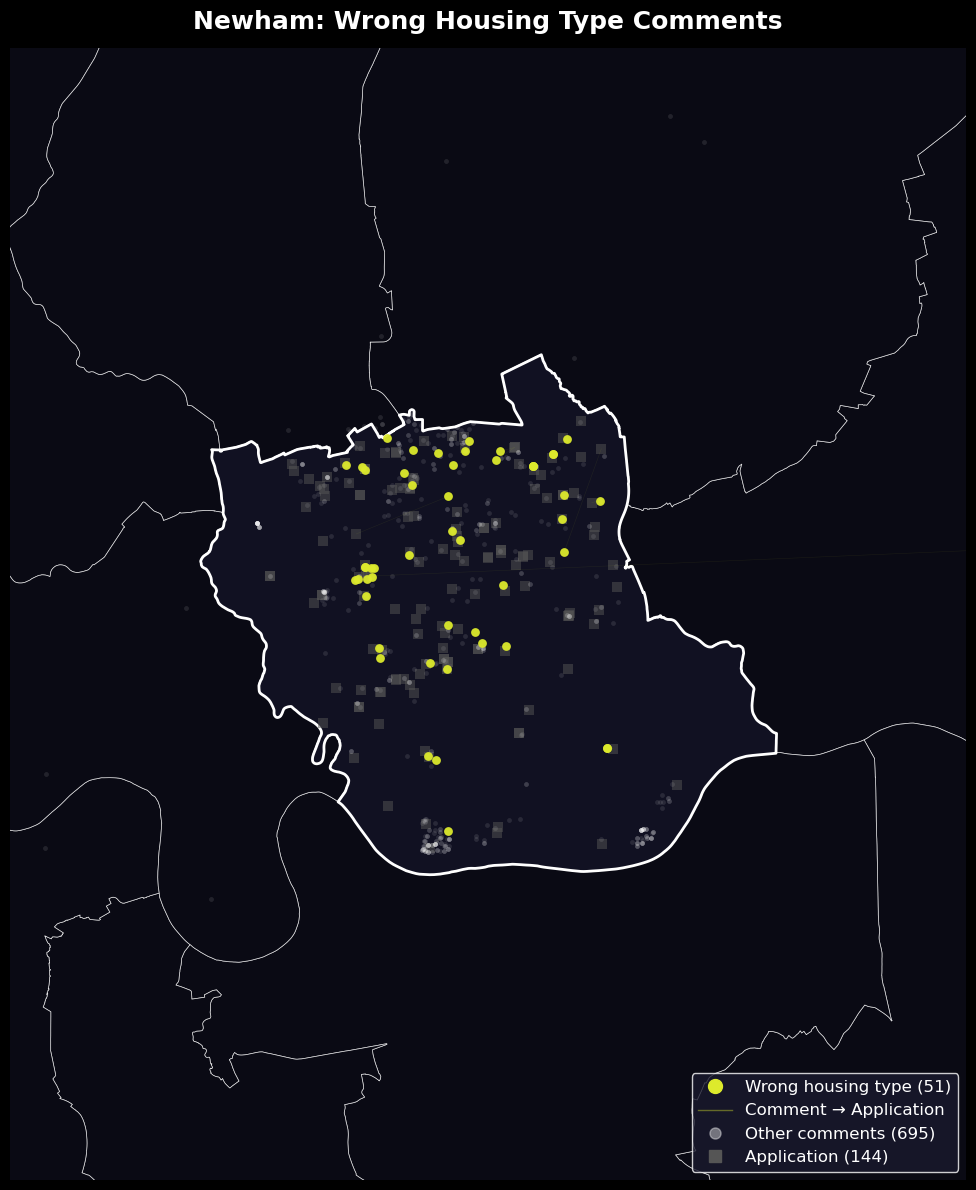

In [14]:

WRONG_COLOR = "#DDEA2C"

has_coords = newham_c.dropna(subset=["lat", "lon"])
wrong      = has_coords[has_coords["wrong_housing"]]
not_wrong  = has_coords[~has_coords["wrong_housing"]]

# Wrong housing comments that also have an application centroid
wrong_linked = wrong.dropna(subset=["centroid_lat", "centroid_lon"])

fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")
_base_map(ax, "Newham: Wrong Housing Type Comments")

ax.scatter(
    app_centroids_commented["centroid_lon"], app_centroids_commented["centroid_lat"],
    color="#555555", s=50, alpha=0.5, zorder=2, linewidths=0, marker="s",
)
ax.scatter(
    not_wrong["lon"], not_wrong["lat"],
    color="white", s=12, alpha=0.1, zorder=3, linewidths=0,
)

# Edges — wrong housing type comments to their applications
for _, row in wrong_linked.iterrows():
    ax.plot(
        [row["lon"], row["centroid_lon"]],
        [row["lat"], row["centroid_lat"]],
        color=WRONG_COLOR, alpha=0.08, linewidth=0.4, zorder=3,
    )

ax.scatter(
    wrong["lon"], wrong["lat"],
    color=WRONG_COLOR, s=40, alpha=0.95, zorder=4, linewidths=0,
)

legend_handles = [
    mlines.Line2D([], [], color=WRONG_COLOR, marker="o", linestyle="None",
                  markersize=10, label=f"Wrong housing type ({len(wrong)})"),
    mlines.Line2D([], [], color=WRONG_COLOR, alpha=0.4, linewidth=1,
                  label="Comment → Application"),
    mlines.Line2D([], [], color="white", marker="o", linestyle="None",
                  markersize=8, alpha=0.4, label=f"Other comments ({len(not_wrong)})"),
    mlines.Line2D([], [], color="#555555", marker="s", linestyle="None",
                  markersize=8, label=f"Application ({len(app_centroids_commented)})"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor="#1a1a2e", edgecolor="white", labelcolor="white", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "newham_wrong_housing_type_map.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Map 4 — Applications with wrong housing type comments

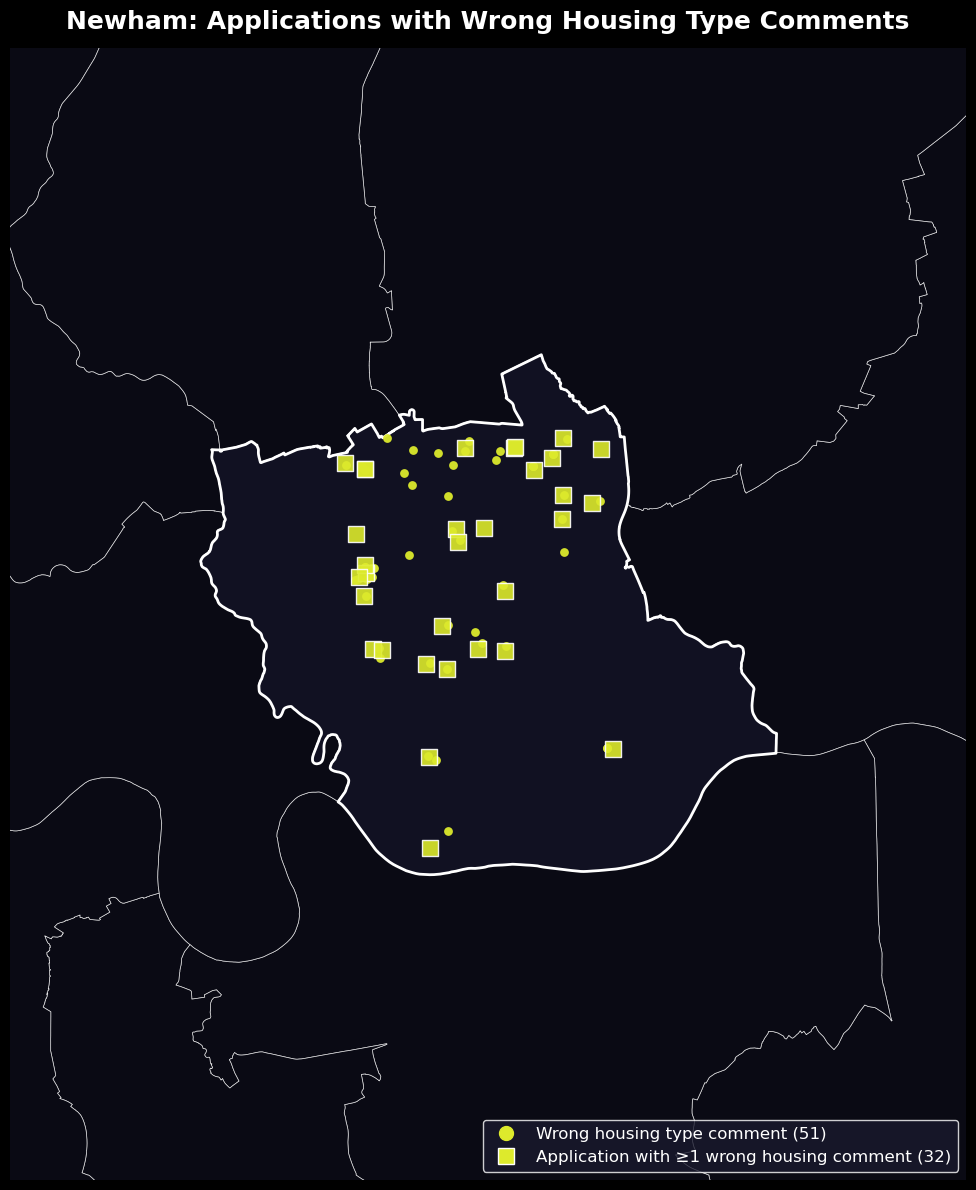

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")
_base_map(ax, "Newham: Applications with Wrong Housing Type Comments")

# Wrong housing type comments
wrong = newham_c[newham_c["wrong_housing"]].dropna(subset=["lat", "lon"])
ax.scatter(
    wrong["lon"], wrong["lat"],
    color=WRONG_COLOR, s=40, alpha=0.95, zorder=3, linewidths=0,
)

# Only applications that have at least one wrong-housing-type comment
ax.scatter(
    app_centroids_wrong_housing["centroid_lon"], app_centroids_wrong_housing["centroid_lat"],
    color=WRONG_COLOR, s=120, alpha=0.9, zorder=4, linewidths=1,
    edgecolors="white", marker="s",
)

legend_handles = [
    mlines.Line2D([], [], color=WRONG_COLOR, marker="o", linestyle="None",
                  markersize=10, label=f"Wrong housing type comment ({len(wrong)})"),
    mlines.Line2D([], [], color=WRONG_COLOR, marker="s", linestyle="None",
                  markersize=12, markeredgecolor="white", markeredgewidth=1,
                  label=f"Application with ≥1 wrong housing comment ({len(app_centroids_wrong_housing)})"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor="#1a1a2e", edgecolor="white", labelcolor="white", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "newham_wrong_housing_applications_map.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
